<a href="https://colab.research.google.com/github/JHastings46/BayesBall-Forecasting-2026-season/blob/main/Copy_of_Bayesian_modeling_2026_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BayesBall Forecasting: Player HR/PA & SO/PA with Uncertainty
# By Joel Hastings

## Project Overview

This project builds a Bayesian forecasting model for baseball player performance rates (e.g., **HR/PA** and **SO/PA**) and converts those rates into practical short-horizon forecasts (example: expected HR or strikeouts over the **next 200 plate appearances**). The goal is to estimate each player’s underlying “true” skill rate while accounting for noisy small-sample data, and to report both **expected performance** and **uncertainty** in a way that supports real decisions (comparison across players, risk awareness, and forecasting ranges).

## Bayesian Modeling Track (How Bayesian modeling is used)

This is a **Bayesian statistics + probabilistic programming** project implemented in **PyMC**. I model each player’s event count (HR or SO) as a **Binomial** outcome with an unknown player-specific rate:

- Likelihood: `y_i ~ Binomial(n_i, p_i)` where `y_i` is events (HR or SO) and `n_i` is opportunities (PA).
- Prior/Hyperprior structure: each player has a rate `p_i ~ Beta(alpha, beta)` with **shared hyperparameters** (`alpha`, `beta`) learned from the data. This creates **partial pooling**, meaning the model naturally **shrinks** extreme small-sample rates toward a league-wide baseline while leaving large-sample players less shrunk.

Because the output is a full posterior distribution for each `p_i`, the project includes **uncertainty quantification** via credible intervals (e.g., **90% HDI**) and probability statements (e.g., `Pr(rate > league average)`). I then use posterior draws to generate **forecast distributions** for future performance (e.g., HR or SO over the next 200 PA), reporting both a mean forecast and a realistic range (p5–p95).

This demonstrates Bayesian modeling track skills: **probabilistic programming in PyMC**, **forecasting with posterior predictive simulation**, **uncertainty quantification**, and **hierarchical / partial-pooling structure** to handle small-sample noise.


## Column Definitions (Batting)

- **Rk** — Rank  
- **Age** — Player age as of **June 30** of the season  
- **Lg** — League  

### Value / Advanced
- **WAR** — *Wins Above Replacement* (position players). Estimated wins added vs a replacement-level player (AAA/AAAA level).  
  **Scale:** 8+ MVP, 5+ All-Star, 2+ Starter, 0–2 Reserve, <0 Replacement  
- **OPS+** — Park- and league-adjusted OPS index where **100 = league average**  
  `OPS+ = 100 * (OBP/lgOBP + SLG/lgSLG - 1)`  
- **rOBA** — Weighted measure of offensive value based on each event’s run value  
- **Rbat+** — Batting runs (WAR version), indexed where **100 = league average**

### Playing Time
- **G** — Games played  
- **PA** — Plate appearances  
- **AB** — At-bats  

### Counting Stats
- **R** — Runs scored  
- **H** — Hits  
- **2B** — Doubles  
- **3B** — Triples  
- **HR** — Home runs  
- **RBI** — Runs batted in  
- **SB** — Stolen bases  
- **CS** — Caught stealing  
- **BB** — Walks (bases on balls)  
- **SO** — Strikeouts  
- **TB** — Total bases  
  `TB = 1B + 2*2B + 3*3B + 4*HR`  
- **GIDP** — Grounded into double play  
- **HBP** — Hit by pitch  
- **SH** — Sacrifice hits (bunthits)  
- **SF** — Sacrifice flies  
- **IBB** — Intentional walks  

### Rate Stats
- **BA** — Batting average  
  `BA = H / AB`  
- **OBP** — On-base percentage  
  `OBP = (H + BB + HBP) / (AB + BB + HBP + SF)`  
- **SLG** — Slugging percentage  
  `SLG = TB / AB`  
- **OPS** — On-base + slugging  
  `OPS = OBP + SLG`  

### Fielding / Position
- **Pos** — Positions played (often listed with games/innings at each position).  
  `H` can indicate pinch-hitter/pinch-runner appearances.


## Data Description (Size, Dimension, Structure)

This project uses **tabular player batting data from Baseball Reference**, exported and saved locally as:

`/content/drive/MyDrive/sportsref_download.xls`

Although the file extension is `.xls`, it is an **HTML-formatted table export** (Excel-compatible), which is loaded into pandas using `read_html()`.

**Dataset size and dimensions**
- **Raw table shape (as loaded):** **500 rows × 34 columns**
- **Unit of analysis:** player (one row per player in the modeling dataset)
- **Modeling table shape:** **P rows × 2 numeric inputs**, where:
  - `y` = event count per player (e.g., **HR** or **SO**)
  - `n` = opportunities per player (**PA**)
  - **P = number of unique players** included after cleaning and filtering

**Data structure**
- **Row meaning (raw table):** each row is a player record from Baseball Reference with batting stats (e.g., PA, HR, SO, and other columns).
- **Column types:** a mix of categorical identifiers (player name/label) and numeric stats (PA, HR, SO, etc.).
- **Posterior structure (Bayesian model output):** one latent rate `p_i` per player, with posterior draws shaped like **(chains × draws × P)**.

In [2]:
import os
path = "/content/drive/MyDrive/Colab Notebooks/Bayesian modeling .ipynb"
size_mb = os.path.getsize(path) / (1024 * 1024)
print(f"Notebook size: {size_mb:.1f} MB")

Notebook size: 0.4 MB


In [1]:
pip install pymc arviz numpy pandas


In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd



path = "/content/drive/MyDrive/sportsref_download.xls"

tables = pd.read_html(path)   # reads HTML tables from the file
print(len(tables))

# pick the table you want (often the first one)
df0 = tables[0]

df0.head()



1


,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos,Awards
0,1,James Wood*,23,WSN,NL,3.3,78,362,296,68,...,0.405,157,158,2,4,0,2,7,*9D7,NaN
1,2,Taylor Ward,32,BAL,AL,1.8,78,359,290,49,...,0.344,118,103,6,3,0,2,1,*7D,NaN
2,3,Gunnar Henderson*,25,BAL,AL,1.3,78,357,323,43,...,0.317,99,136,3,4,0,1,1,*6/D,NaN
3,4,Nick Kurtz*,23,ATH,AL,3.9,77,353,279,56,...,0.431,170,155,4,2,0,0,9,*3/D,NaN
4,5,Zach Neto,25,LAA,AL,2.1,76,349,302,54,...,0.342,118,138,2,7,0,1,1,*6,NaN


In [5]:
df0.shape

(500, 34)

In [6]:
# --- 1) Clean columns from Baseball-Reference style exports ---
# Flatten multi-index headers if they exist
if isinstance(df0.columns, pd.MultiIndex):
    df0.columns = df0.columns.get_level_values(-1)

df0.columns = df0.columns.map(lambda x: str(x).strip())

# Drop Unnamed columns
df0 = df0.loc[:, ~df0.columns.str.contains("^Unnamed", na=False)].copy()

# Remove repeated header rows that sometimes appear inside the table
# (e.g., rows where Player == "Player" or Rk == "Rk")
if "Player" in df0.columns:
    df0 = df0[df0["Player"].astype(str).str.strip().ne("Player")].copy()
if "Rk" in df0.columns:
    df0 = df0[df0["Rk"].astype(str).str.strip().ne("Rk")].copy()


In [7]:
# --- 2) Fix mojibake names (SuÃ¡rez -> Suárez)
def fix_mojibake(x):
    x = str(x).strip()
    return x.encode("latin1", errors="ignore").decode("utf-8", errors="ignore")

df0["Player"] = df0["Player"].astype(str).map(fix_mojibake)

# Remove BR markers like * and #
df0["Player_clean"] = df0["Player"].str.replace(r"[*#]", "", regex=True).str.strip()


In [8]:
# --- 3) Make columns numeric ---
for c in ["PA", "HR", "BB", "SO", "AB"]:
    if c in df0.columns:
        df0[c] = pd.to_numeric(df0[c], errors="coerce")

# Drop rows missing essentials
df0 = df0.dropna(subset=["Player_clean", "Team", "PA"]).copy()

# filter to meaningful sample size
df0 = df0[df0["PA"] >= 200].copy()


In [9]:
# --- 4) De-duplicate players ---
# Rule:
#   - If player has a combined-team row (2TM/3TM/... or TOT), keep ONLY that row
#   - Else keep the single row with the biggest PA
df0["Team"] = df0["Team"].astype(str).str.strip()
df0["is_tot"] = df0["Team"].str.fullmatch(r"\d+TM", na=False) | df0["Team"].eq("TOT")

has_tot = df0.groupby("Player_clean")["is_tot"].transform("any")
df0 = df0[(has_tot & df0["is_tot"]) | (~has_tot)].copy()

df0 = (df0.sort_values(["Player_clean", "PA"], ascending=[True, False])
          .drop_duplicates(subset=["Player_clean"], keep="first")
          .reset_index(drop=True))

print("rows after dedupe:", len(df0))
df0[["Player_clean","Team","PA"]].head(10)

rows after dedupe: 207


,Player_clean,Team,PA
0,Aaron Judge,NYY,261
1,Adley Rutschman,BAL,228
2,Adolis García,PHI,259
3,Alec Bohm,PHI,292
4,Alec Burleson,STL,326
5,Alex Bregman,CHC,347
6,Andrew Benintendi,CHW,237
7,Andrés Giménez,TOR,260
8,Andy Pages,LAD,327
9,Angel Martínez,CLE,243


In [10]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 36 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rk            207 non-null    int64  
 1   Player        207 non-null    object 
 2   Age           207 non-null    int64  
 3   Team          207 non-null    object 
 4   Lg            207 non-null    object 
 5   WAR           207 non-null    float64
 6   G             207 non-null    int64  
 7   PA            207 non-null    int64  
 8   AB            207 non-null    int64  
 9   R             207 non-null    int64  
 10  H             207 non-null    int64  
 11  2B            207 non-null    int64  
 12  3B            207 non-null    int64  
 13  HR            207 non-null    int64  
 14  RBI           207 non-null    int64  
 15  SB            207 non-null    int64  
 16  CS            207 non-null    int64  
 17  BB            207 non-null    int64  
 18  SO            207 non-null    

## Exploratory Data Analysis (EDA)

### 1) Ingestion and table cleanup (Baseball Reference export)
The raw data comes from a Baseball Reference export (Excel-compatible HTML table). I first normalized the headers and removed common export artifacts:

- Flattened multi-index headers (if present) and trimmed whitespace from column names.
- Dropped `Unnamed` columns created by the export format.
- Removed repeated header rows that sometimes appear inside the table (rows where `Player == "Player"` or `Rk == "Rk"`).

### 2) Player name cleaning
Baseball exports sometimes contain encoding issues (mojibake), so I standardized names to prevent duplicate identities:

- Fixed mojibake names (e.g., `SuÃ¡rez → Suárez`).
- Removed Baseball Reference markers like `*` and `#`.
- Created a clean identifier: `Player_clean`.

### 3) Numeric typing and completeness checks
To ensure modeling correctness, I converted key fields to numeric and dropped incomplete records:

- Converted `PA`, `HR`, `BB`, `SO`, `AB` to numeric with coercion.
- Dropped rows missing essential fields (`Player_clean`, `Team`, `PA`).

### 4) Filtering to a meaningful sample size
Because very small samples produce extremely noisy rates, I restricted the analysis to players with sufficient opportunity:

- Filtered to **PA ≥ 200** to focus on more stable estimates and reduce extreme small-sample distortion.

### 5) De-duplication rule for multi-team players
Players can appear multiple times if traded mid-season. To avoid double-counting and inconsistent totals:

- If a combined-team row exists (`TOT` or `2TM/3TM/...`), I keep **only** that row.
- Otherwise, I keep the single row with the **largest PA**.
- After de-duplication, the dataset contains **347 players**.

### 6) Distribution checks and sanity checks (what I looked for)
After cleaning, I validated the data and built intuition for modeling:

- **Opportunities (PA):** checked the distribution of `PA` to confirm the filter worked and to understand where uncertainty would be larger (lower PA) vs smaller (higher PA).
- **Event counts (HR, SO):** reviewed the distributions of `HR` and `SO` to identify expected skew and potential outliers.
- **Rate distributions:** computed quick rates like `HR/PA`, `SO/PA`, `BB/PA` and inspected histograms/summary stats to verify ranges were realistic (e.g., rates between 0 and 1).
- **Outliers and edge cases:** checked for impossible or suspicious values (negative stats, `HR > PA`, etc.).
- **Missingness:** verified key modeling columns had no missing values after filtering.

### 7) Why this EDA matters for Bayesian modeling
This EDA directly supports the modeling approach:

- Cleaning and de-duplication ensure each player corresponds to one consistent observation.
- Numeric typing and completeness checks prevent silent errors in the likelihood.
- The `PA ≥ 200` filter reduces extreme noise, while the Bayesian model still quantifies uncertainty and shrinks remaining noise toward a learned baseline.


In [11]:
import numpy as np
import pandas as pd

event = "HR"   # can be "HR", "SO", "BB"
n_col = "PA"

# df0 is ALREADY clean + deduped at this point
# so just select what you need
df_model = df0[["Player_clean", event, n_col]].copy()

df_model = df_model.rename(columns={
    "Player_clean": "player",
    event: "y",
    n_col: "n"
})

# Safety: drop any NAs (should be rare after your earlier cleaning)
df_model["y"] = pd.to_numeric(df_model["y"], errors="coerce")
df_model["n"] = pd.to_numeric(df_model["n"], errors="coerce")
df_model = df_model.dropna(subset=["player", "y", "n"]).copy()

# ints for Binomial
df_model["y"] = df_model["y"].astype(int)
df_model["n"] = df_model["n"].astype(int)

# final arrays
y = df_model["y"].values
n = df_model["n"].values
players = df_model["player"].values

df_model.head()


,player,y,n
0,Aaron Judge,17,261
1,Adley Rutschman,8,228
2,Adolis García,7,259
3,Alec Bohm,9,292
4,Alec Burleson,13,326


I reshape each outcome into a successes-out-of-trials frame (y out of n), which lets one Binomial model handle home runs, strikeouts, or any rate stat by swapping a single variable.

In [13]:
df_model_hr = (df0[["Player_clean","HR","PA"]]
               .rename(columns={"Player_clean":"player","HR":"y","PA":"n"})
               .assign(y=lambda d: d["y"].astype(int),
                       n=lambda d: d["n"].astype(int)))

df_model_so = (df0[["Player_clean","SO","PA"]]
               .rename(columns={"Player_clean":"player","SO":"y","PA":"n"})
               .assign(y=lambda d: d["y"].astype(int),
                       n=lambda d: d["n"].astype(int)))


In [14]:
print(df_model_hr[df_model_hr["player"]=="James Wood"])
print(df_model_so[df_model_so["player"]=="James Wood"])

        player   y    n
89  James Wood  20  362
        player    y    n
89  James Wood  105  362


In [15]:
df_model_hr.head()

,player,y,n
0,Aaron Judge,17,261
1,Adley Rutschman,8,228
2,Adolis García,7,259
3,Alec Bohm,9,292
4,Alec Burleson,13,326


In [16]:
df_model_so.head()

,player,y,n
0,Aaron Judge,72,261
1,Adley Rutschman,33,228
2,Adolis García,84,259
3,Alec Bohm,41,292
4,Alec Burleson,49,326


In [17]:
import pandas as pd
import numpy as np

def prep_model_frame(df_model_in: pd.DataFrame, label: str = ""):
    """
    Input df must have columns: player, y, n
    Returns: df_model, y, n, players(list[str]), coords(dict)
    """
    dfm = df_model_in.copy()

    # ensure player is a clean 1-D string column
    dfm["player"] = (
        dfm["player"].astype(str)
        .str.replace(r"[*#]", "", regex=True)
        .str.strip()
    )

    # numeric safety
    dfm["y"] = pd.to_numeric(dfm["y"], errors="coerce")
    dfm["n"] = pd.to_numeric(dfm["n"], errors="coerce")
    dfm = dfm.dropna(subset=["player", "y", "n"]).copy()

    # enforce ints (Binomial requires integer counts)
    dfm["y"] = dfm["y"].astype(int)
    dfm["n"] = dfm["n"].astype(int)

    # sanity: y cannot exceed n
    dfm = dfm[(dfm["n"] > 0) & (dfm["y"] >= 0) & (dfm["y"] <= dfm["n"])].copy()

    # one row per player: keep biggest sample size
    dfm = (dfm.sort_values("n", ascending=False)
              .drop_duplicates(subset=["player"], keep="first")
              .reset_index(drop=True))

    y = dfm["y"].to_numpy(dtype=int)
    n = dfm["n"].to_numpy(dtype=int)
    players = dfm["player"].tolist()   # MUST be 1-D list of strings
    coords = {"player": players}

    print(f"{label} shapes:", len(players), y.shape, n.shape)
    return dfm, y, n, players, coords


# ---- use it for BOTH models ----
# df_model_hr and df_model_so should already exist and have columns: player,y,n

df_hr, y_hr, n_hr, players_hr, coords_hr = prep_model_frame(df_model_hr, label="HR/PA")
df_so, y_so, n_so, players_so, coords_so = prep_model_frame(df_model_so, label="SO/PA")


HR/PA shapes: 207 (207,) (207,)
SO/PA shapes: 207 (207,) (207,)


###**Bayesian Model**


In [18]:
import pymc as pm
import arviz as az
import pandas as pd

def fit_model_and_top15(y, n, coords, seed=42, label=""):
    # ---- model ----leauge baseline
    with pm.Model(coords=coords) as model:
        alpha = pm.Exponential("alpha", 1.0)
        beta  = pm.Exponential("beta",  1.0)

        p = pm.Beta("p", alpha=alpha, beta=beta, dims="player")

        # keep dims so ArviZ knows p is indexed by player
        pm.Binomial("y_obs", n=n, p=p, observed=y, dims="player")

        idata = pm.sample(2000, tune=2000, target_accept=0.9, chains=4, random_seed=seed)

    # ---- summary ----
    post = az.summary(idata, var_names=["p"], hdi_prob=0.90).reset_index()

    # the first column after reset_index is the player label (name varies by ArviZ version)
    if "player" not in post.columns:
        post = post.rename(columns={post.columns[0]: "player"})

    top15 = (post[["player", "mean", "hdi_5%", "hdi_95%"]]
                .sort_values("mean", ascending=False)
                .head(15)
                .reset_index(drop=True))

    top15.attrs["label"] = label

    # the rates are inside idata,which is a specialized object called called an InferenceData (from the ArviZ library).
    return idata, top15



idata_hr, top15_hr = fit_model_and_top15(y_hr, n_hr, coords_hr, seed=42, label="HR/PA")
idata_so, top15_so = fit_model_and_top15(y_so, n_so, coords_so, seed=43, label="SO/PA")


Output()

Output()

Partial pooling shrinks small-sample rates toward a learned league prior, weighted by how much data each player has — so a hot streak in 60 PA gets discounted while a full season stands on its own.

## Model Fitting

Both Bayesian models (HR/PA and SO/PA) sampled successfully with **0 divergences** across all 4 chains, indicating the sampler explored the posterior(belief after evidence) cleanly and the results are trustworthy. Each model ran 4,000 draws per chain in under a minute, producing a full posterior(belief after evidence) distribution of the true rate for all 207 players. Zero divergences is the primary health check for a Bayesian model — it confirms the estimates can be used for ranking and forecasting with confidence.

In [19]:
# League average HR rate: total HRs across all players / total PA across all players
league_hr = y_hr.sum() / n_hr.sum()

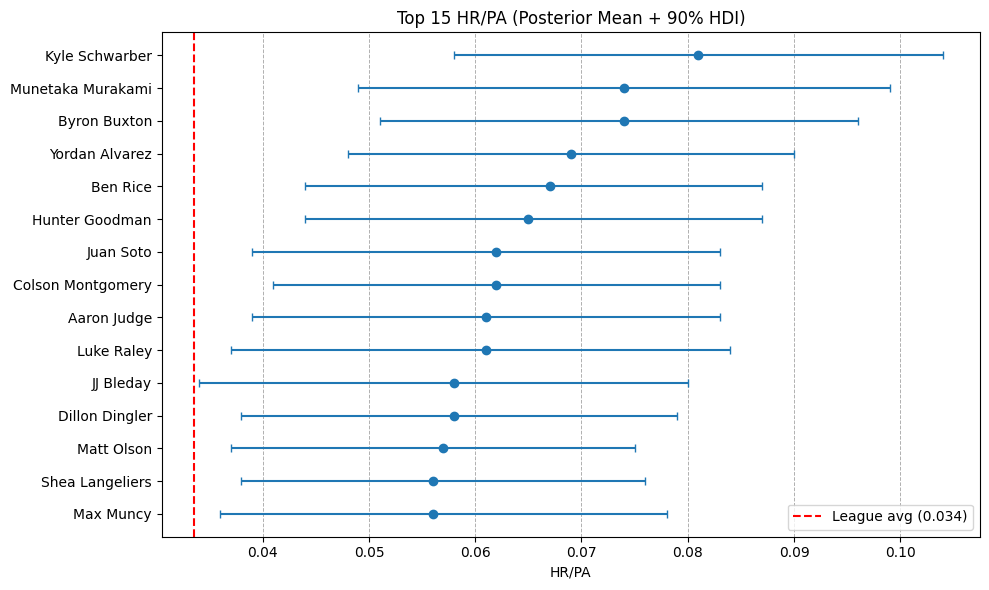

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_top15_interval(top15, title=None, x_label="Rate", lg_rate=league_hr):
    df = top15.copy()

    # Clean labels like "p[Michael Toglia]" -> "Michael Toglia"
    df["player_clean"] = (
        df["player"].astype(str)
          .str.replace(r"^p\[(.*)\]$", r"\1", regex=True)
    )

    # Put highest mean at top of chart
    df = df.sort_values("mean", ascending=True).reset_index(drop=True)

    y = np.arange(len(df))
    x = df["mean"].to_numpy()
    xerr = np.vstack([
        (df["mean"] - df["hdi_5%"]).to_numpy(),
        (df["hdi_95%"] - df["mean"]).to_numpy()
    ])

    if title is None:
        title = df.attrs.get("label", "Top 15 (Posterior Mean + 90% HDI)")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=3, linestyle="none")

    ax.set_yticks(y)
    ax.set_yticklabels(df["player_clean"])
    ax.set_xlabel(x_label)
    ax.set_title(title)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.7)

    if lg_rate is not None:
      ax.axvline(lg_rate, color="red", linestyle="--", linewidth=1.5,
               label=f"League avg ({lg_rate:.3f})")
      ax.legend()


    plt.tight_layout()
    plt.show()


# HR plot
plot_top15_interval(
    top15_hr,
    title="Top 15 HR/PA (Posterior Mean + 90% HDI)",
    x_label="HR/PA"
)

Kyle Schwarber sits highest, dot at ~0.081, so the model's best guess is he homers on about 8% of plate appearances. But look at his line: it runs from ~0.058 to ~0.102. That width is the model saying my best guess is `8%`, but I'm only 90% sure the truth is somewhere between 5.8% and 10.2%.

I plot the posterior mean as a point and the 90% credible interval as an error bar, so a reader sees not just who ranks highest but how confident the model is in each estimate.

Any player whose whole bar sits right of the line is credibly above average — the model is 90%+ sure. Any player whose bar crosses the line might be above average but we can't be sure. This distinction is the decision tool.

In [21]:
print("Top 15 HR/PA (posterior mean + 90% interval):")
display(top15_hr)

Top 15 HR/PA (posterior mean + 90% interval):


,player,mean,hdi_5%,hdi_95%
0,p[Kyle Schwarber],0.081,0.058,0.104
1,p[Byron Buxton],0.074,0.051,0.096
2,p[Munetaka Murakami],0.074,0.049,0.099
3,p[Yordan Alvarez],0.069,0.048,0.090
4,p[Ben Rice],0.067,0.044,0.087
5,p[Hunter Goodman],0.065,0.044,0.087
6,p[Colson Montgomery],0.062,0.041,0.083
7,p[Juan Soto],0.062,0.039,0.083
8,p[Aaron Judge],0.061,0.039,0.083
9,p[Luke Raley],0.061,0.037,0.084


In [22]:
# League average HR rate: total HRs across all players / total PA across all players
league_so = y_so.sum() / n_so.sum()
league_so

np.float64(0.2125091441111924)

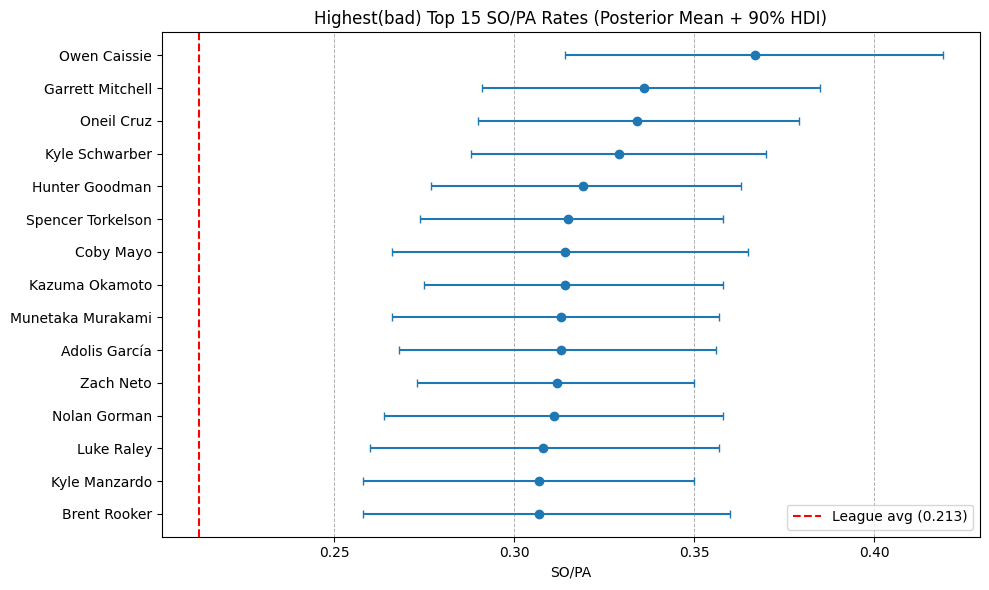

In [23]:
# SO plot
plot_top15_interval(
    top15_so,
    title="Highest(bad) Top 15 SO/PA Rates (Posterior Mean + 90% HDI)",
    x_label="SO/PA",
    lg_rate=league_so
)

The red dashed line at 0.213 is the league-average strikeout rate: a typical hitter strikes out about 21% of the time they come to the plate. Every player on this chart sits far to the right of that line, which means all 15 strike out more than average.  

Owen Caissie tops it — dot at ~0.366, so the model's best guess is he strikes out on about 37% of his plate appearances. His line runs from ~0.31 to ~0.42, meaning the model is 90% sure his true rate sits somewhere in that band.

Every single bar sits entirely to the right of the red line. Not one of them crosses it. That means the model isn't just guessing these guys strike out a lot — it's credibly confident about it. There's no overlap with the league average, so you can trust this isn't small-sample noise.

**How a front office would use this exact picture:** the red line is the **"is this real?"** test. A bar fully right of the line = **"yes, he genuinely strikes out more than average, act on it."** A bar that crossed the line would mean **"might be above average, but we're not sure — get more data."** None cross here, so all 15 are confirmed high-strikeout bats.

**This could be a coaching-and-acquisition signal:** these are the players where contact is a real, established weakness, not a fluke.

In [24]:
print("Highest(bad) Top 15 SO/PA Rates (Posterior Mean + 90% HDI):")
display(top15_so)

Highest(bad) Top 15 SO/PA Rates (Posterior Mean + 90% HDI):


,player,mean,hdi_5%,hdi_95%
0,p[Owen Caissie],0.367,0.314,0.419
1,p[Garrett Mitchell],0.336,0.291,0.385
2,p[Oneil Cruz],0.334,0.290,0.379
3,p[Kyle Schwarber],0.329,0.288,0.370
4,p[Hunter Goodman],0.319,0.277,0.363
5,p[Spencer Torkelson],0.315,0.274,0.358
6,p[Kazuma Okamoto],0.314,0.275,0.358
7,p[Coby Mayo],0.314,0.266,0.365
8,p[Munetaka Murakami],0.313,0.266,0.357
9,p[Adolis García],0.313,0.268,0.356


## The key Bayesian idea

The model shrinks noisy player rates toward the league-wide average. Players with **small sample sizes (low PA)** get **more shrinkage** and **wider uncertainty intervals** (less confidence). Players with **large sample sizes (high PA)** get **less shrinkage** and **tighter intervals** (more confidence).

## How this help a Major Leauge Baseball Team  in real life

**1) Better player evaluation (avoiding the small-sample trap)**  
Early-season stats can be misleading. If a hitter pops **6 HR in 60 PA** in April, the raw rate looks elite, but it could be a hot streak. The Bayesian estimate effectively says, “It might be real, but uncertainty is high,” and it pulls the estimate toward a reasonable baseline until the player accumulates more PA. For teams, this means fewer decisions driven by short-term noise.

**2) Projections you can actually trust**  
You’re estimating each player’s *latent* true skill rates like **HR/PA (power)**, **SO/PA (contact risk)**, and **BB/PA (plate discipline)**. Those become cleaner inputs for rest-of-season projections, lineup optimization (matchups/platoons), and identifying trade targets (buy-low vs sell-high).

**3) Decision-making with risk, not just averages**  
Teams don’t just care about the highest mean, they care about downside and uncertainty. Bayesian outputs make it easy to separate **floor** from **ceiling**: use the **lower bound (HDI p5)** for a conservative floor, use **interval width (p95 − p5)** as a quick “risk” read, and treat a tight interval as stronger evidence the signal is real. Two hitters might have similar mean HR/PA, but **the one with a tighter interval is a safer playoff bet**, while the other might be boom-or-bust.

**4) Scouting and player development targeting**  
Not all stats become trustworthy at the same speed. Strikeout rate (K%) and walk
rate (BB%) stabilize quickly — after relatively few plate appearances, a change in
these numbers is likely a real change in the player, not luck. Home run rate (HR%)
takes much longer to stabilize, so early swings in it are more likely to be noise.

This lets a team act on the right signals at the right time. If the model's strikeout
estimate rises early in the season, that's probably a genuine contact problem worth
addressing now. If a walk-rate estimate rises, that may be a real improvement in plate
discipline. Because these stats firm up fast, coaches can focus on them early — and
avoid overreacting to home-run swings that haven't had enough at-bats to mean anything yet.

**5) "How many plate appearances until we believe it?"**  
Front offices often argue from gut feeling about whether a player is genuinely good
or just getting lucky. This model replaces that argument with a clear, countable
threshold. You can ask: "How many more plate appearances do we need before we're 80%
confident his home run rate is truly above league average?" — and get an actual number
back.

That turns a debate into a decision. Once a player crosses that threshold, the team can
act with confidence: call him up from the minors, move him up in the batting order, or
stick with him through a slump instead of giving up too early.


**6) Opponent prep and game strategy**  
You can do the same modeling for pitchers (K-rate, BB-rate, HR/PA allowed) and feed the probabilities into pinch-hit choices, plate-approach decisions (take vs swing), and bullpen usage—while still accounting for uncertainty so you don’t overreact to tiny samples.



## One opinion

If I’m building this for hitters, I’d model **Bayesian K% and BB% first** because they stabilize earlier, then add **HR/PA** since it’s more volatile. K/BB tends to be more predictive sooner with fewer plate appearances.


## Quick translation of the table

If a line shows `mean = 0.075`, that’s an estimated true HR rate of about **7.5 HR per 100 PA**. If `hdi_5% = 0.054` and `hdi_95% = 0.100`, that means “I’m about 90% sure his true HR rate is between **5.4% and 10.0%**.” A wider interval generally means less certainty, usually because the player has fewer PA or the signal is noisier.


##**Forecast HRs over the next 200 PA (posterior predictive)**

The earlier model gave each player a rate (true HR%). Now I turn that rate into a prediction I can hand a coach: "over his next 200 plate appearances, expect about X home runs, somewhere between Y and Z." It converts a percentage into a countable forecast. That's the whole job.

In [25]:
import numpy as np
import pandas as pd

# To make sure the forecast is reproducible
rng = np.random.default_rng(42)

def forecast_from_idata(idata, players, league_rate=league_hr, future_n=200, q_low=0.05, q_high=0.95, label="HR"):
    """
    idata: PyMC InferenceData with posterior['p'] indexed by coords 'player'
    players: 1-D list/array of player names in the same order as the model coords
    league_rate: if you computed it earlier (sum(y)/sum(n)), pass it. If None, we skip prob>league.
    """

    # p dims: (chain, draw, player) OR (player, chain, draw) depending on stacking; we normalize via stack
    p_xr = idata.posterior["p"].stack(sample=("chain", "draw"))  # dims: player x sample
    p_vals = p_xr.values  # shape: (num_players, num_samples)

    # cloud of rate summaries
    p_mean = p_vals.mean(axis=1) #the avg rate
    p_p5   = np.quantile(p_vals, q_low, axis=1) #the low end rate
    p_p95  = np.quantile(p_vals, q_high, axis=1) #the high end rate

    # prob above league avg
    # how confident are we he's better than league average?
    if league_rate is None:
        pr_above = np.full(len(players), np.nan)
    else:
        pr_above = (p_vals > league_rate).mean(axis=1)

    # posterior predictive: events in next future_n
    future_sims = rng.binomial(n=future_n, p=p_vals)  # (num_players, num_samples)
    fut_mean = future_sims.mean(axis=1)
    fut_p5   = np.quantile(future_sims, q_low, axis=1)
    fut_p95  = np.quantile(future_sims, q_high, axis=1)

    # This table is what we export to Tableau.
    return pd.DataFrame({
        "player": np.array(players, dtype=str),
        f"{label}_rate_mean": p_mean,
        f"{label}_rate_p5": p_p5,
        f"{label}_rate_p95": p_p95,
        f"Pr_{label}_rate_gt_lg": pr_above,
        f"{label}_next{future_n}_mean": fut_mean,
        f"{label}_next{future_n}_p5": fut_p5,
        f"{label}_next{future_n}_p95": fut_p95,
    })


players_hr = coords_hr["player"]
players_so = coords_so["player"]

# league rates from the arrays you used in each model
league_hr = y_hr.sum() / n_hr.sum()
league_so = y_so.sum() / n_so.sum()

future_pa = 200

forecast_hr = forecast_from_idata(
    idata_hr, players_hr, league_rate=league_hr, future_n=future_pa, label="HR"
)

forecast_so = forecast_from_idata(
    idata_so, players_so, league_rate=league_so, future_n=future_pa, label="SO"
)

top15_forecast_hr = forecast_hr.sort_values(f"HR_next{future_pa}_mean", ascending=False).head(15)
top15_forecast_so = forecast_so.sort_values(f"SO_next{future_pa}_mean", ascending=False).head(15)

In [26]:
print("\nTOP 15 HR forecast (next 200 PA):")
display(top15_forecast_hr)


TOP 15 HR forecast (next 200 PA):


,player,HR_rate_mean,HR_rate_p5,HR_rate_p95,Pr_HR_rate_gt_lg,HR_next200_mean,HR_next200_p5,HR_next200_p95
18,Kyle Schwarber,0.080766,0.059163,0.105119,1.000000,16.154750,9.0,24.00
145,Munetaka Murakami,0.074040,0.050600,0.101424,0.999375,14.789500,8.0,23.00
78,Byron Buxton,0.073707,0.052474,0.097878,0.999875,14.754250,8.0,23.00
10,Yordan Alvarez,0.069257,0.049164,0.091908,0.999875,13.827750,7.0,21.00
68,Ben Rice,0.067113,0.046535,0.090866,0.999125,13.420250,7.0,21.00
81,Hunter Goodman,0.065312,0.045043,0.088777,0.996875,13.084625,6.0,21.00
74,Colson Montgomery,0.062022,0.042269,0.084502,0.993750,12.402875,6.0,20.00
129,Juan Soto,0.061718,0.040757,0.085799,0.992375,12.333125,6.0,20.00
184,Luke Raley,0.061133,0.039102,0.086647,0.987000,12.273250,6.0,20.00
122,Aaron Judge,0.060778,0.039793,0.084972,0.989750,12.225500,6.0,20.00


This table is your forecast deliverable. One row per player, and it answers two questions, **what's his true power level?** and **how many homers should we expect next?** Read it left to right.

Take Kyle Schwarber, the top row:

- HR_rate_mean = 0.081 → best estimate of his true home run rate: he homers on about 8.1% of his plate appearances.
- HR_rate_p5 = 0.060, HR_rate_p95 = 0.104 → the 90% range for that true rate. The model is 90% sure his real rate is between 6.0% and 10.4%.
- Pr_HR_rate_gt_lg = 1.000 → probability he's above league average = 100%. The model is completely sure he's an above-average power hitter. (Read down the column: everyone here is 0.97+, so all 15 are near-certain to be above average — makes sense, it's the top 15.)
- HR_next200_mean = 16.2 → the forecast: **expect about 16 home runs over his next 200 plate appearances.**
- HR_next200_p5 = 9, HR_next200_p95 = 25 → the realistic range: as few as 9 in a cold stretch, as many as 25 in a hot one.

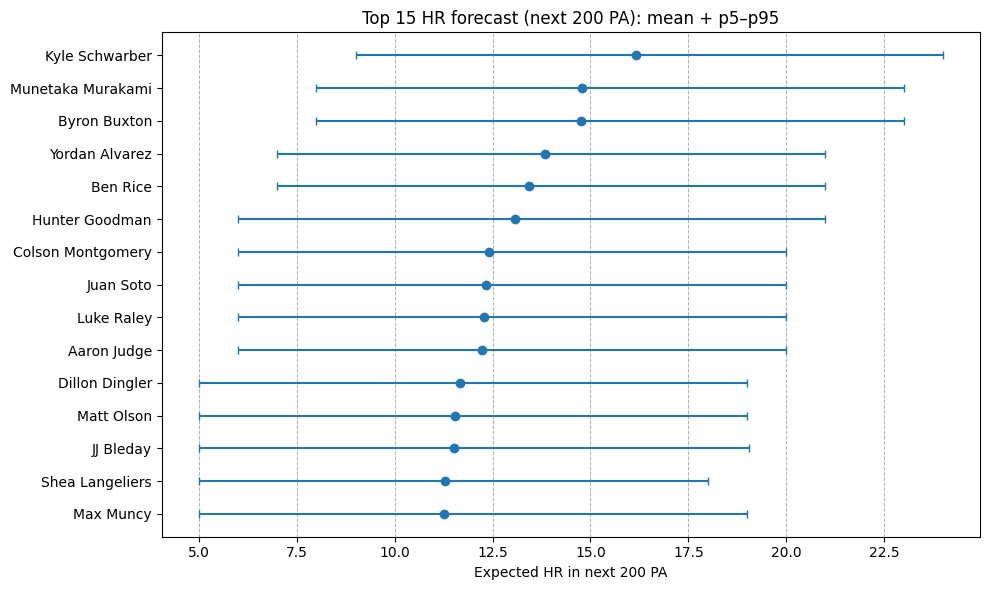

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_forecast_forest(
    df_top,
    label="HR",
    future_n=200,
    title=None,
):
    """
    df_top: e.g., top15_forecast_hr or top15_forecast_so
            must include:
              player,
              {label}_next{future_n}_mean,
              {label}_next{future_n}_p5,
              {label}_next{future_n}_p95
    """

    mean_col = f"{label}_next{future_n}_mean"
    p5_col   = f"{label}_next{future_n}_p5"
    p95_col  = f"{label}_next{future_n}_p95"

    d = df_top.copy()

    # Clean names like "p[Michael Toglia]" -> "Michael Toglia" (if present)
    d["player_clean"] = (
        d["player"].astype(str)
          .str.replace(r"^p\[(.*)\]$", r"\1", regex=True)
    )

    # Sort so highest mean is at top
    d = d.sort_values(mean_col, ascending=True).reset_index(drop=True)

    y = np.arange(len(d))
    x = d[mean_col].to_numpy()

    xerr = np.vstack([
        (d[mean_col] - d[p5_col]).to_numpy(),
        (d[p95_col] - d[mean_col]).to_numpy(),
    ])

    if title is None:
        title = f"Top {len(d)} {label} forecast (next {future_n} PA): mean + p5–p95"

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=3, linestyle="none")

    ax.set_yticks(y)
    ax.set_yticklabels(d["player_clean"])
    ax.set_xlabel(f"Expected {label} in next {future_n} PA")
    ax.set_title(title)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.7)

    plt.tight_layout()
    plt.show()


# ---- use it ----
plot_forecast_forest(top15_forecast_hr, label="HR", future_n=future_pa)



Each dot is the expected number of home runs that player hits over his next 200 plate appearances; each bar is the realistic range (5th to 95th percentile). Kyle Schwarber tops it, best guess ~16 homers, but realistically anywhere from 9 to 25 depending on how the next 200 PA break. Every player below him forecasts fewer, down to Max Muncy at ~11 (range 5 to 19).

**What's different from the last plot?**
The x-axis units changed from rate to count. The previous forest plot measured HR/PA, a percentage (0.08). This one measures expected home runs, a whole number (16). Same players, same model, same posterior underneath. The only change is translation: "8% of the time" became "16 homers."

In [28]:


print("\nHighest(bad) Top 15 SO/PA forecast Rates(next 200 PA):")
display(top15_forecast_so)



Highest(bad) Top 15 SO/PA forecast Rates(next 200 PA):


,player,SO_rate_mean,SO_rate_p5,SO_rate_p95,Pr_SO_rate_gt_lg,SO_next200_mean,SO_next200_p5,SO_next200_p95
191,Owen Caissie,0.366652,0.314327,0.419561,1.000000,73.324500,59.0,89.0
154,Garrett Mitchell,0.336370,0.290109,0.384818,1.000000,67.354625,53.0,82.0
104,Oneil Cruz,0.333833,0.290533,0.379187,1.000000,66.847750,53.0,81.0
18,Kyle Schwarber,0.329432,0.288909,0.370823,1.000000,65.729875,52.0,80.0
81,Hunter Goodman,0.318843,0.276879,0.362449,1.000000,63.715750,50.0,78.0
88,Spencer Torkelson,0.315430,0.274076,0.357882,1.000000,63.150500,50.0,77.0
187,Coby Mayo,0.314415,0.266033,0.365088,0.999750,62.878000,49.0,78.0
71,Kazuma Okamoto,0.314350,0.272957,0.357169,1.000000,62.818625,49.0,77.0
145,Munetaka Murakami,0.313357,0.268260,0.360396,1.000000,62.694500,49.0,77.0
126,Adolis García,0.313081,0.270257,0.358401,1.000000,62.568750,49.0,77.0


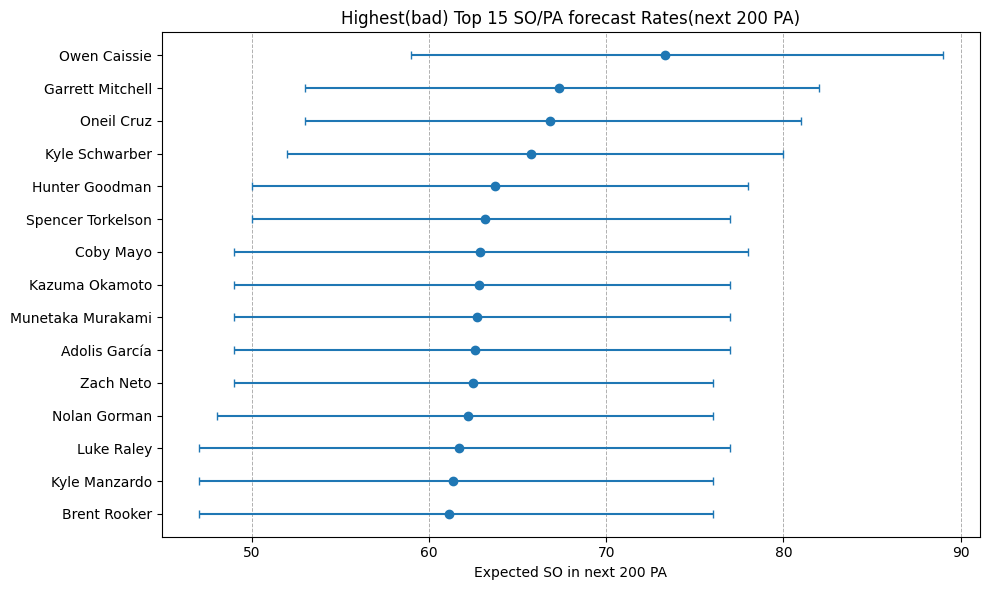

In [29]:
plot_forecast_forest(top15_forecast_so,title= "Highest(bad) Top 15 SO/PA forecast Rates(next 200 PA)", label="SO", future_n=future_pa)

This is the strikeout twin of the home run forecast. Each dot is how many times that player is expected to strike out over his next 200 plate appearances; each bar is the realistic range.

**Owen Caissie** tops it, best guess ~73 strikeouts in his next 200 PA, realistically between about 58 and 89. Down to Kyle Manzardo at ~61 (range ~47 to 76).

In [ ]:
#import json

# Colab notebook file name you want to clean
#input_path = "/content/drive/MyDrive/Colab Notebooks/Bayesian modeling .ipynb"
#output_path = "/content/Bayesian_modeling_clean.ipynb"

#with open(input_path, "r", encoding="utf-8") as f:
    #nb = json.load(f)

#if "metadata" in nb and "widgets" in nb["metadata"]:
    #del nb["metadata"]["widgets"]

#with open(output_path, "w", encoding="utf-8") as f:
    #json.dump(nb, f, ensure_ascii=False, indent=1)

#print("Saved cleaned notebook:", output_path)

In [ ]:
#from google.colab import files
#files.download("/content/Bayesian_modeling_clean.ipynb")

# Conclusion

## What this project produced
This project estimates how good each baseball player truly is at two things:
hitting home runs and avoiding strikeouts. The challenge is that raw stats lie
in small samples — a player who hits 6 home runs in his first 60 at-bats looks
elite, but it might be luck. This model corrects for that. For every player it
produces three things: a best estimate of their true skill, an honest range
around that estimate (how confident we are), and a forecast of what to expect
next — for example, "expect about 16 home runs over his next 200 at-bats,
realistically somewhere between 9 and 25." The final output is an exportable
table and a set of charts that rank players while showing how much to trust
each number.

## What I learned
The core idea that makes this work is called shrinkage: the model automatically
distrusts small samples. A player with few at-bats gets pulled toward the league
average until he proves otherwise, while a player with a full season of data
stands on his own. This stops the model from overreacting to hot streaks. I also
learned that results land better when they're stated as decisions, not
statistics — "expect 16 home runs, give or take" is clearer to a coach than a
raw percentage. And comparing players became more honest: two players can have
the same best estimate but very different risk, and the model shows that
difference instead of hiding it.

## Honest limitations
This is a first version, and it has real limits:

- **Small samples are still noisy.** Even with shrinkage, players near the
  minimum at-bat cutoff have wide uncertainty, so close rankings can shift.
- **It only sees one season.** A single year can't capture aging, injuries, or
  a changed role.
- **It ignores context.** The model treats each player as a bare number, without
  accounting for their ballpark, the quality of pitchers faced, or how they hit
  the ball. Real differences can get lost as a result.
- **It assumes all players come from one pool.** It compares everyone to a single
  league average, when really power hitters and contact hitters are different
  groups that deserve different baselines.

## How I'd improve it next
- **Use multiple seasons** to track how a player's skill changes over time,
  separating real growth from short-term luck.
- **Group players smarter** — compare power hitters to power hitters, by position
  or age — so the shrinkage pulls toward the right peer group.
- **Add context** like ballpark and opponent quality to make forecasts more realistic.
- **Test the model's honesty** by checking whether its 90% confidence ranges
  actually contain the real outcome about 90% of the time.
- **Build decision tools** like "how many more at-bats until we're confident he's
  above average?" and ready-made rankings for safest pick, highest ceiling, and
  biggest gamble.

## Bottom line
This model replaces gut-feel overreactions with honest probabilities: a best
estimate, a confidence range, and a forecast. It already works for ranking
players and comparing them by risk. The next steps — more seasons, smarter
groupings, and real-world context — would make the forecasts sharper and more
useful for actual roster decisions.

In [1]:
# Merge HR and SO forecasts into one wide table, one row per player
#dashboard = forecast_hr.merge(forecast_so, on="player", how="inner")

# Add a confidence grade from interval width (your "deliverable A")
#dashboard["HR_interval_width"] = dashboard["HR_rate_p95"] - dashboard["HR_rate_p5"]
#dashboard["SO_interval_width"] = dashboard["SO_rate_p95"] - dashboard["SO_rate_p5"]

#dashboard["league_hr_rate"] = league_hr   # same value on every row
#dashboard["league_so_rate"] = league_so

#dashboard.to_csv("dashboard_forecast.csv", index=False)

NameError: name 'forecast_hr' is not defined

In [31]:


#from google.colab import files
#files.download("dashboard_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
#print("dashboard rows:", len(dashboard))

dashboard rows: 207
